# 04 — Dashboard
All charts in one place. Run the cells in order.

## Setup and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Colours
BLUE, LIGHT_BLUE, NAVY = "#2563EB", "#93C5FD", "#1D4ED8"
DARK, GRAY             = "#1E293B", "#64748B"
GREEN, RED, AMBER, BG  = "#16A34A", "#DC2626", "#D97706", "#F8FAFC"

# Load and clean
tickets   = pd.read_csv("it_support_tickets.csv", parse_dates=["created_at"])
customers = pd.read_csv("customer_info_1000.csv")

df = tickets.merge(customers[["customer_id", "country", "city"]], on="customer_id", how="left")

country_to_region = {
    "United States": "NA",  "Canada": "NA",    "Mexico": "NA",
    "Germany": "EU",        "France": "EU",    "United Kingdom": "EU",
    "Spain": "EU",          "Italy": "EU",     "Netherlands": "EU",
    "Sweden": "EU",         "Poland": "EU",    "Belgium": "EU",
    "China": "APAC",        "Japan": "APAC",   "India": "APAC",
    "Australia": "APAC",    "South Korea": "APAC", "Singapore": "APAC",
    "Brazil": "LATAM",      "Argentina": "LATAM",  "Colombia": "LATAM",
    "Chile": "LATAM",       "Peru": "LATAM",
    "South Africa": "MEA",  "Nigeria": "MEA",  "Kenya": "MEA",
    "Saudi Arabia": "MEA",  "UAE": "MEA",      "Egypt": "MEA",
}
mask = df["region"].isna()
df.loc[mask, "region"] = df.loc[mask, "country"].map(country_to_region)
df = df.dropna(subset=["region"])
df["csat_score"]  = df["csat_score"].replace(0, np.nan)
df["year_month"]  = df["created_at"].dt.to_period("M").astype(str)
df["is_resolved"] = df["status"].isin(["resolved", "closed_no_action"])

resolved = df.dropna(subset=["resolution_time_hours"])
csat_df  = df.dropna(subset=["csat_score"])

print("Loaded", len(df), "tickets")

Loaded 82706 tickets


## Mask sensitive columns

In [2]:
import hashlib

def hash_value(val):
    if pd.isna(val):
        return val
    return hashlib.sha256(str(val).encode()).hexdigest()[:16]

pii_columns = ["customer_name", "contact_person", "email_address", "Address_line_1"]
for col in pii_columns:
    if col in customers.columns:
        customers[col] = customers[col].apply(hash_value)

print("PII columns masked.")


PII columns masked.


## Key metrics

In [3]:
print(f"Total tickets:          {len(df):,}")
print(f"Resolution rate:        {df['is_resolved'].mean()*100:.1f}%")
print(f"Median resolution time: {resolved['resolution_time_hours'].median():.1f}h")
print(f"Reopen rate:            {df['reopened'].mean()*100:.1f}%")
print(f"CSAT response rate:     {len(csat_df)/len(df)*100:.1f}%")
print(f"Average CSAT:           {csat_df['csat_score'].mean():.2f} / 5")

Total tickets:          82,706
Resolution rate:        60.1%
Median resolution time: 29.9h
Reopen rate:            5.1%
CSAT response rate:     70.1%
Average CSAT:           3.20 / 5


## Figure 1 — Main dashboard (6 panels)

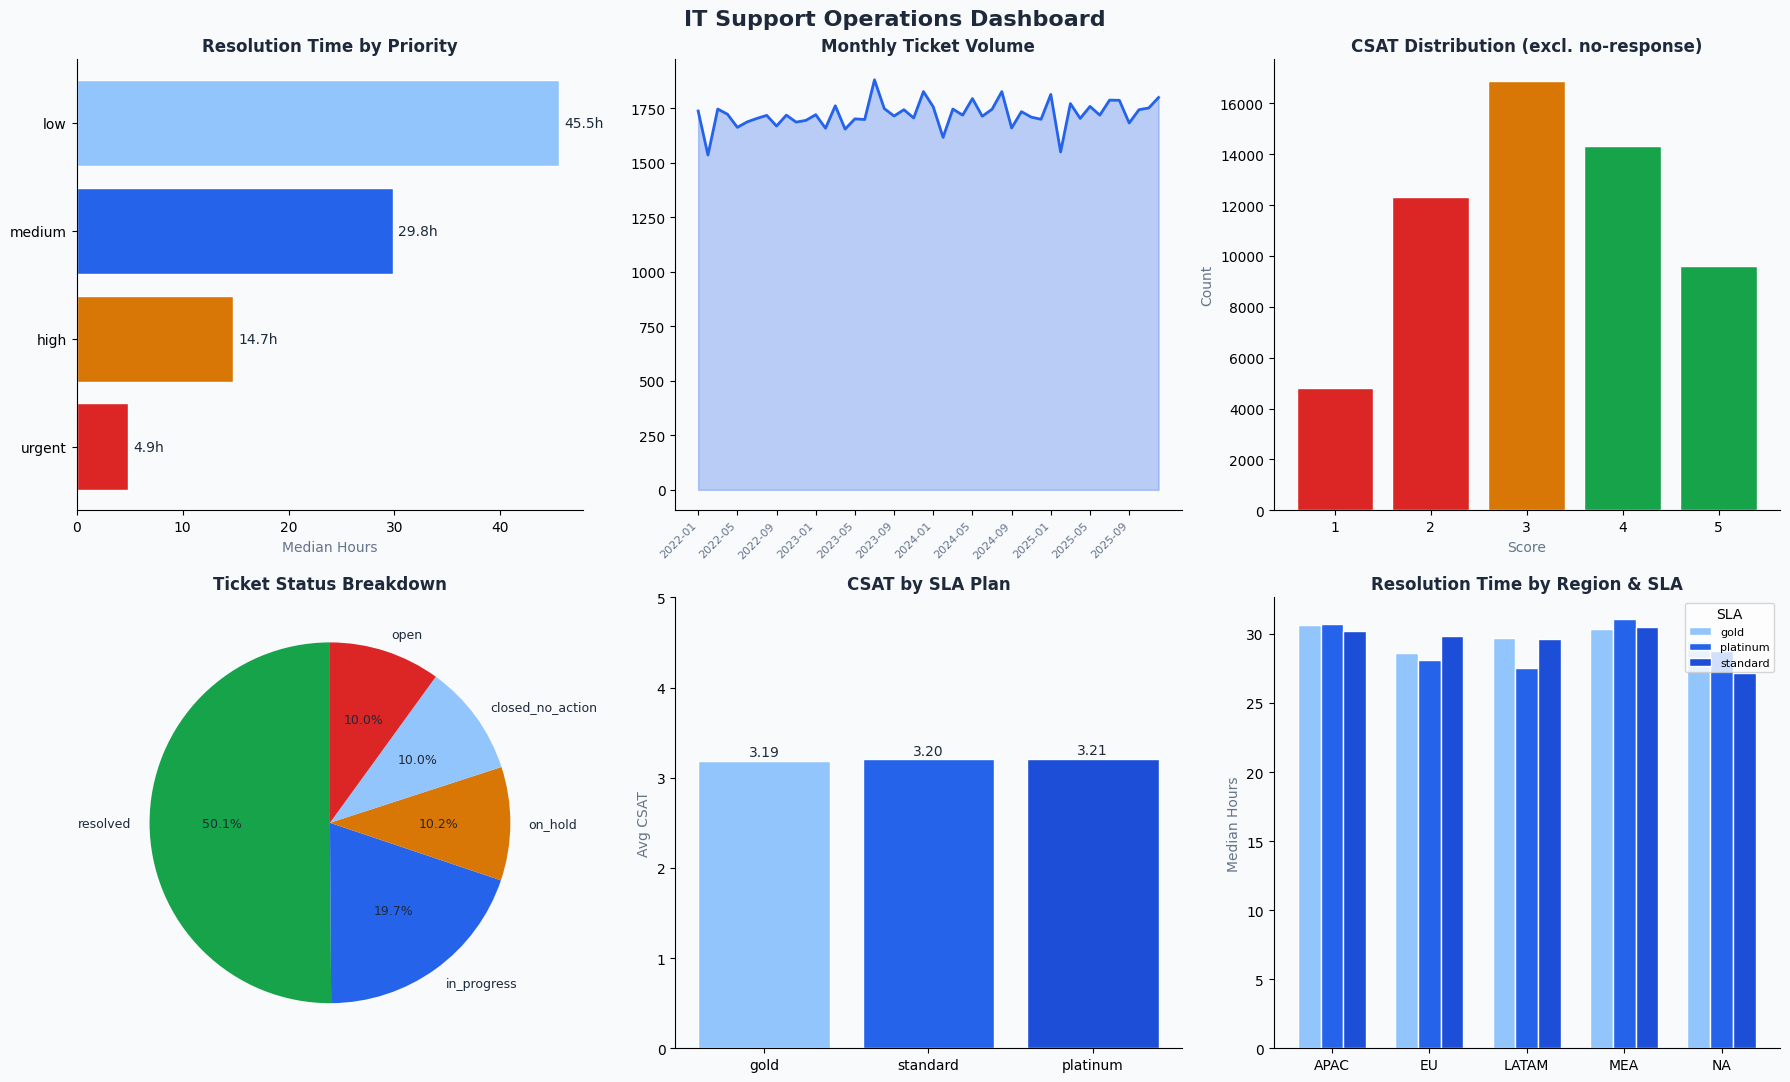

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(BG)
fig.suptitle("IT Support Operations Dashboard", fontsize=16, fontweight="bold", color=DARK)

# Panel 1: Resolution time by priority
ax = axes[0, 0]
med = resolved.groupby("priority")["resolution_time_hours"].median().reindex(["urgent","high","medium","low"])
bars = ax.barh(["urgent","high","medium","low"], med.values, color=[RED,AMBER,BLUE,LIGHT_BLUE], edgecolor="white")
for bar, val in zip(bars, med.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}h", va="center", color=DARK)
ax.set_title("Resolution Time by Priority", fontweight="bold", color=DARK)
ax.set_xlabel("Median Hours", color=GRAY)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

# Panel 2: Monthly ticket volume
ax = axes[0, 1]
monthly = df.groupby("year_month").size().reset_index(name="n").sort_values("year_month")
x = range(len(monthly))
ax.fill_between(x, monthly["n"], alpha=0.3, color=BLUE)
ax.plot(x, monthly["n"], color=BLUE, linewidth=2)
ticks = [i for i in x if i % 4 == 0]
ax.set_xticks(ticks)
ax.set_xticklabels([monthly["year_month"].iloc[i] for i in ticks], rotation=45, ha="right", fontsize=8, color=GRAY)
ax.set_title("Monthly Ticket Volume", fontweight="bold", color=DARK)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

# Panel 3: CSAT distribution
ax = axes[0, 2]
csat_counts = csat_df["csat_score"].value_counts().sort_index()
ax.bar(csat_counts.index, csat_counts.values, color=[RED,RED,AMBER,GREEN,GREEN], edgecolor="white")
ax.set_title("CSAT Distribution (excl. no-response)", fontweight="bold", color=DARK)
ax.set_xlabel("Score", color=GRAY); ax.set_ylabel("Count", color=GRAY)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

# Panel 4: Status breakdown
ax = axes[1, 0]
status = df["status"].value_counts()
ax.pie(status.values, labels=status.index, autopct="%1.1f%%",
       colors=[GREEN,BLUE,AMBER,LIGHT_BLUE,RED], startangle=90,
       textprops={"fontsize": 9, "color": DARK})
ax.set_title("Ticket Status Breakdown", fontweight="bold", color=DARK)

# Panel 5: CSAT by SLA plan
ax = axes[1, 1]
csat_sla = csat_df.groupby("sla_plan")["csat_score"].mean().sort_values()
ax.bar(csat_sla.index, csat_sla.values, color=[LIGHT_BLUE, BLUE, NAVY], edgecolor="white")
ax.set_ylim(0, 5); ax.set_ylabel("Avg CSAT", color=GRAY)
ax.set_title("CSAT by SLA Plan", fontweight="bold", color=DARK)
for i, (_, val) in enumerate(csat_sla.items()):
    ax.text(i, val + 0.05, f"{val:.2f}", ha="center", color=DARK)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

# Panel 6: Resolution time by region and SLA
ax = axes[1, 2]
pivot = resolved.groupby(["region","sla_plan"])["resolution_time_hours"].median().unstack()
pivot.plot(kind="bar", ax=ax, color=[LIGHT_BLUE,BLUE,NAVY], edgecolor="white", width=0.7)
ax.set_title("Resolution Time by Region & SLA", fontweight="bold", color=DARK)
ax.set_ylabel("Median Hours", color=GRAY); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0); ax.legend(title="SLA", fontsize=8)
ax.set_facecolor(BG); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Figure 2 — Resolution time distribution by priority

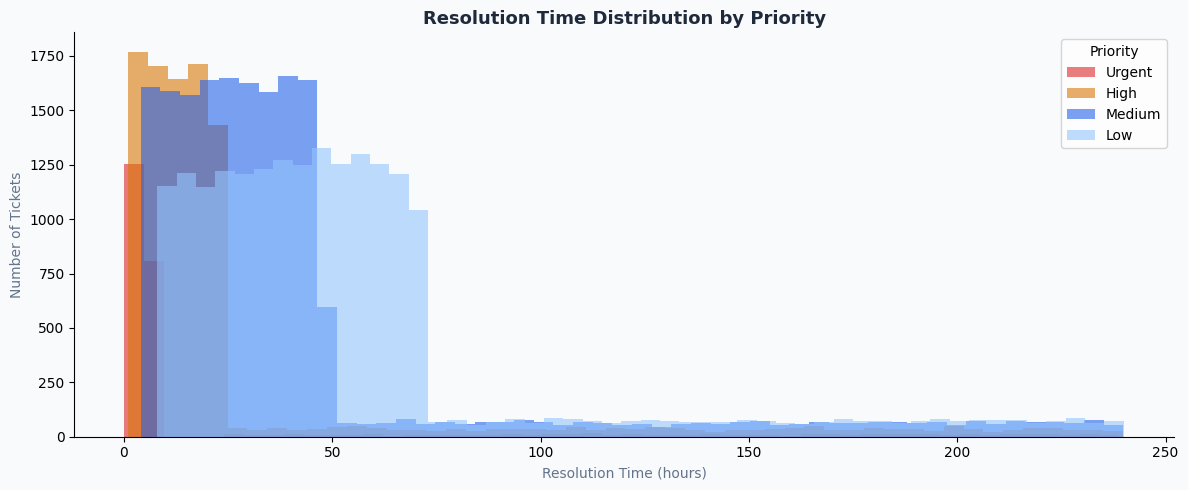

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

for priority, color in zip(["urgent","high","medium","low"], [RED,AMBER,BLUE,LIGHT_BLUE]):
    data = resolved[resolved["priority"] == priority]["resolution_time_hours"]
    ax.hist(data, bins=50, alpha=0.6, label=priority.capitalize(), color=color, edgecolor="none")

ax.set_xlabel("Resolution Time (hours)", color=GRAY)
ax.set_ylabel("Number of Tickets", color=GRAY)
ax.set_title("Resolution Time Distribution by Priority", fontsize=13, fontweight="bold", color=DARK)
ax.spines[["top","right"]].set_visible(False)
ax.legend(title="Priority")
plt.tight_layout()
plt.show()

## Figure 3 — Ticket volume by channel and issue type

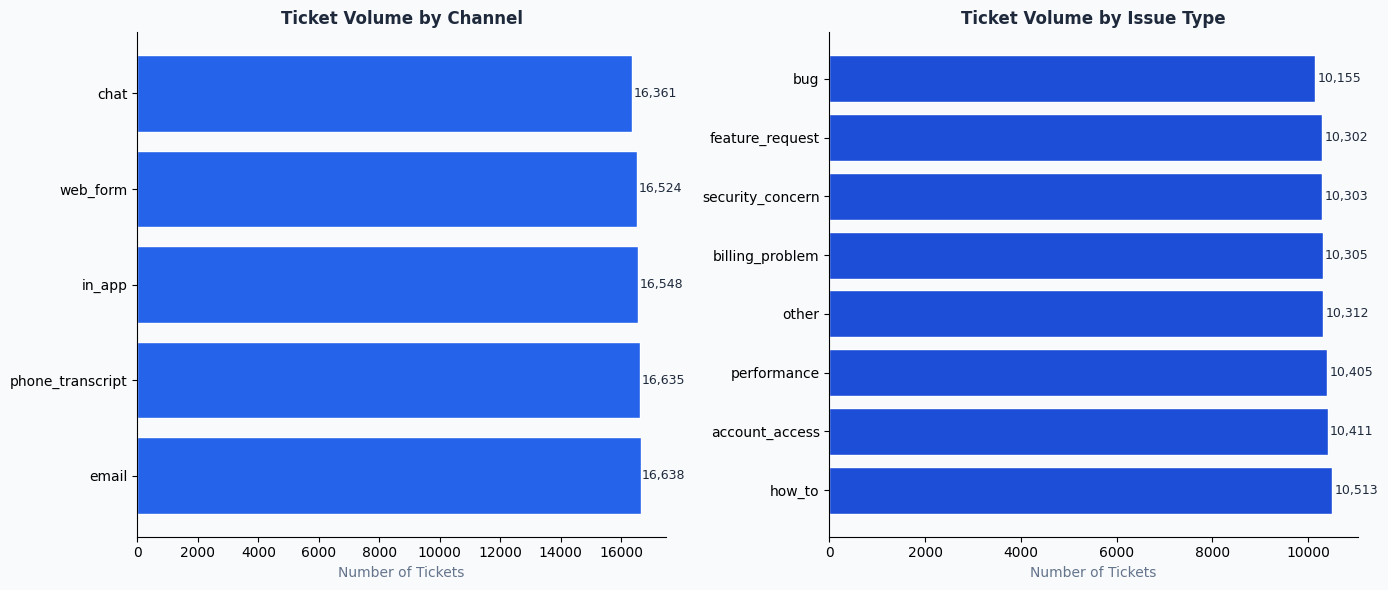

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

# Channel
channel_counts = df["channel"].value_counts()
axes[0].barh(channel_counts.index, channel_counts.values, color=BLUE, edgecolor="white")
for i, val in enumerate(channel_counts.values):
    axes[0].text(val + 50, i, f"{val:,}", va="center", fontsize=9, color=DARK)
axes[0].set_title("Ticket Volume by Channel", fontweight="bold", color=DARK)
axes[0].set_xlabel("Number of Tickets", color=GRAY)
axes[0].set_facecolor(BG); axes[0].spines[["top","right"]].set_visible(False)

# Issue type
issue_counts = df["issue_type"].value_counts()
axes[1].barh(issue_counts.index, issue_counts.values, color=NAVY, edgecolor="white")
for i, val in enumerate(issue_counts.values):
    axes[1].text(val + 50, i, f"{val:,}", va="center", fontsize=9, color=DARK)
axes[1].set_title("Ticket Volume by Issue Type", fontweight="bold", color=DARK)
axes[1].set_xlabel("Number of Tickets", color=GRAY)
axes[1].set_facecolor(BG); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Figure 4 — CSAT heatmap by customer segment and region

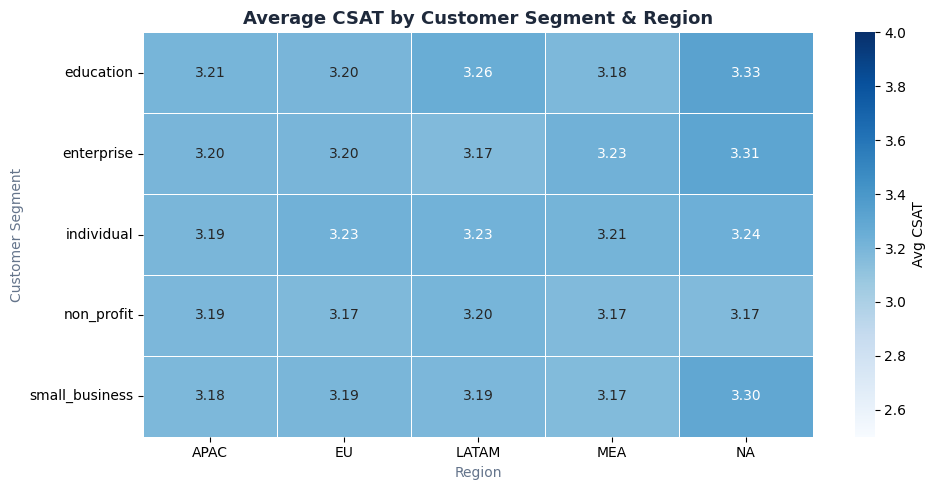

In [7]:
pivot = (
    csat_df
    .groupby(["customer_segment", "region"])["csat_score"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=2.5, vmax=4,
            cbar_kws={"label": "Avg CSAT"})
ax.set_title("Average CSAT by Customer Segment & Region", fontsize=13, fontweight="bold", color=DARK)
ax.set_xlabel("Region", color=GRAY)
ax.set_ylabel("Customer Segment", color=GRAY)
plt.tight_layout()
plt.show()

## Figure 5 — CSAT and reopen rate by issue type

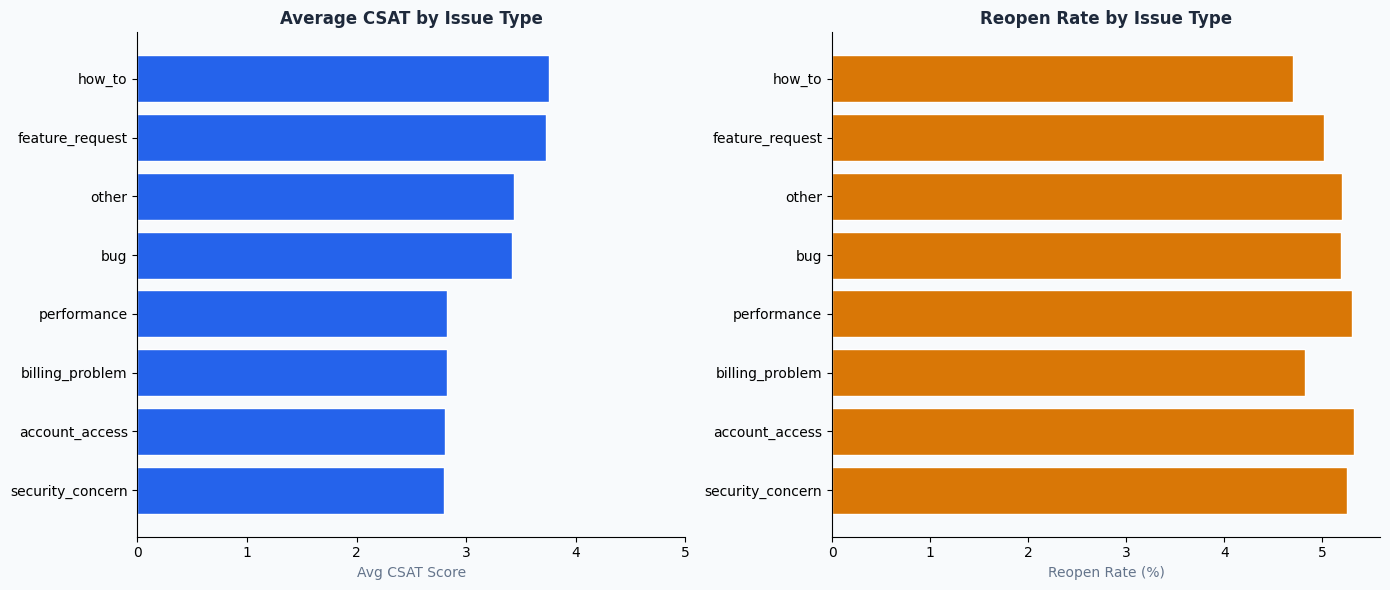

In [8]:
issue_stats = (
    df.groupby("issue_type")
    .agg(avg_csat=("csat_score","mean"), reopen_rate=("reopened","mean"))
    .sort_values("avg_csat")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

axes[0].barh(issue_stats.index, issue_stats["avg_csat"], color=BLUE, edgecolor="white")
axes[0].set_xlim(0, 5)
axes[0].set_title("Average CSAT by Issue Type", fontweight="bold", color=DARK)
axes[0].set_xlabel("Avg CSAT Score", color=GRAY)
axes[0].set_facecolor(BG); axes[0].spines[["top","right"]].set_visible(False)

axes[1].barh(issue_stats.index, issue_stats["reopen_rate"] * 100, color=AMBER, edgecolor="white")
axes[1].set_title("Reopen Rate by Issue Type", fontweight="bold", color=DARK)
axes[1].set_xlabel("Reopen Rate (%)", color=GRAY)
axes[1].set_facecolor(BG); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Figure 6 — Product area breakdown

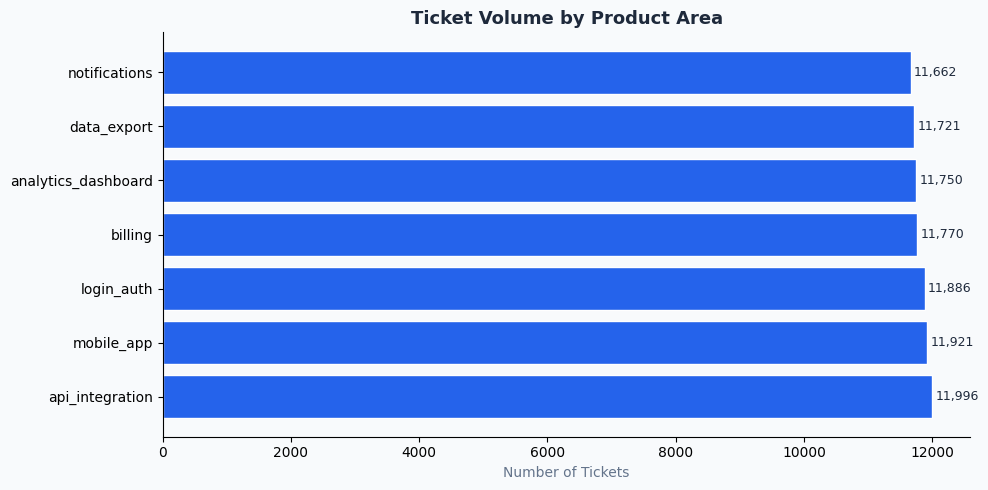

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

product_counts = df["product_area"].value_counts()
ax.barh(product_counts.index, product_counts.values, color=BLUE, edgecolor="white")
for i, val in enumerate(product_counts.values):
    ax.text(val + 50, i, f"{val:,}", va="center", fontsize=9, color=DARK)

ax.set_title("Ticket Volume by Product Area", fontsize=13, fontweight="bold", color=DARK)
ax.set_xlabel("Number of Tickets", color=GRAY)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Figure 7 — Sentiment distribution

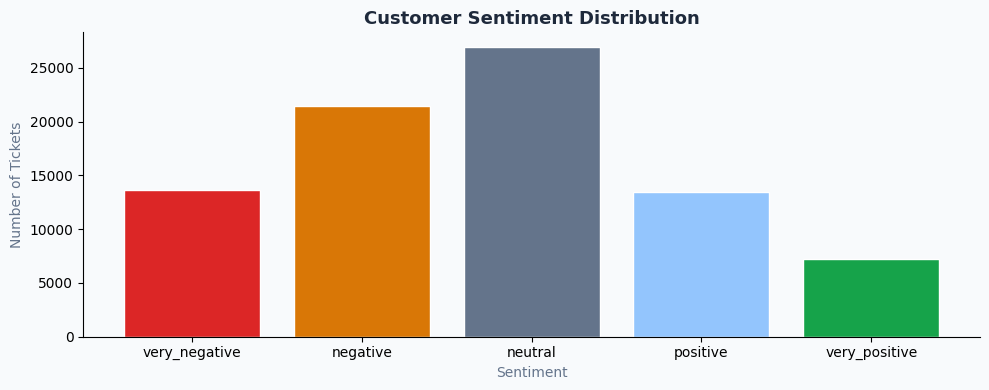

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

sentiment_order = ["very_negative", "negative", "neutral", "positive", "very_positive"]
sentiment_colors = [RED, AMBER, GRAY, LIGHT_BLUE, GREEN]
sentiment_counts = df["customer_sentiment"].value_counts().reindex(sentiment_order)

ax.bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors, edgecolor="white")
ax.set_title("Customer Sentiment Distribution", fontsize=13, fontweight="bold", color=DARK)
ax.set_xlabel("Sentiment", color=GRAY)
ax.set_ylabel("Number of Tickets", color=GRAY)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()